# 01 — Shape Quantization Smoke Test

이 notebook의 목적은 **Phase 1 — Shape Quantization**을 빠르게 검증하는 것입니다.

질문:

> 비슷한 OHLCV candle shape를 같은 learned token으로 묶을 수 있는가?

범위:

- 단일 `market × symbol × timeframe`
- DuckDB `ohlcv_bars`에서 이미 수집된 데이터만 사용
- `CandleBar → 7D FeatureVector → VQ-VAE → shape token`
- Phase 1 metric 중심: `token_utilization`, `semantic_consistency`
- Phase 2 metric은 맛보기로 `transition_report`만 확인

주의:

- 여기서 생성되는 token은 **shape token**입니다.
- 아직 `market state token`이라고 부르지 않습니다.
- future return, trading signal, backtest는 이 notebook 범위 밖입니다.

## 0. Environment Check

필요한 optional dependency:

```bash
uv sync --extra tokenizers
```

Jupyter kernel 등록 예시:

```bash
uv run --extra tokenizers --with ipykernel python -m ipykernel install --user --name finlabs-tokenizers --display-name "FinLabs Tokenizers"
```

이 프로젝트는 현재 `package = false`로 로컬 개발 중이므로, 다음 code cell이 repo root를 찾아 `sys.path`에 추가합니다. notebook을 `research/notebooks/`에서 열어도 `kis_cli`와 `research` import가 가능해야 합니다.

개발 중 Python module을 수정하면 Jupyter kernel이 예전 import를 캐시할 수 있습니다. 그래서 다음 셀에서 `%autoreload 2`를 켭니다. 그래도 같은 traceback이 반복되면 `Kernel → Restart Kernel and Run All Cells`를 실행하세요.


In [48]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "kis_cli").is_dir() and (candidate / "research").is_dir():
            return candidate
    raise RuntimeError(
        "FinLabs repo root를 찾지 못했습니다. "
        "notebook을 finlabs repository 안에서 실행하고 있는지 확인하세요."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: /Users/choeseoggyu/portfolio/finlabs


In [49]:
%load_ext autoreload
%autoreload 2

print("autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
autoreload enabled


In [50]:
from pathlib import Path

try:
    import torch
except ImportError as exc:
    raise RuntimeError(
        "이 notebook은 optional tokenizer dependency가 필요합니다. "
        "먼저 `uv sync --extra tokenizers`를 실행하세요."
    ) from exc

print("torch", torch.__version__)

torch 2.12.0


## 1. Experiment Config

먼저 하나의 market/symbol/interval만 선택합니다. 데이터가 없는 경우 `kis_cli`로 OHLCV를 먼저 수집해야 합니다.

예시:

```bash
uv run python -m kis_cli chart daily --symbol AAPL --start 2020-01-01 --end 2026-01-01 --save
```

In [51]:
from kis_cli.storage.warehouse import default_warehouse_file

MARKET = "NASDAQ"
SYMBOL = "NVDA"
INTERVAL = "1m"

# "ratio" is safer for minute data whose absolute date range is unknown.
# Use "date" when you want explicit calendar boundaries.
SPLIT_MODE = "ratio"  # "ratio" or "date"
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

TRAIN_END = "2024-12-31"
VAL_END = "2025-12-31"

CODEBOOK_SIZE = 16
LATENT_DIM = 16
HIDDEN_DIM = 64
EPOCHS = 20
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
SEED = 42

WAREHOUSE_PATH = default_warehouse_file()
RUN_DIR = REPO_ROOT / "research" / "runs" / f"shape_quantization_{MARKET}_{SYMBOL}_{INTERVAL}_k{CODEBOOK_SIZE}"

WAREHOUSE_PATH, RUN_DIR

(PosixPath('/Users/choeseoggyu/Library/Application Support/kis-cli/warehouse.duckdb'),
 PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16'))

## 2. Load Candles

DuckDB warehouse의 `ohlcv_bars`에서 timestamp 오름차순으로 candle을 읽습니다.

In [52]:
from research.tokenizers.data import load_candles, split_by_date, split_by_ratio

candles = load_candles(
    WAREHOUSE_PATH,
    market=MARKET,
    symbol=SYMBOL,
    interval=INTERVAL,
)

print("candles:", len(candles))
if not candles:
    raise RuntimeError(
        f"No candles found for market={MARKET}, symbol={SYMBOL}, interval={INTERVAL}. "
        "먼저 kis_cli로 OHLCV 데이터를 수집하세요."
    )

candles[:3], candles[-3:]

candles: 12000


((CandleBar(market='NASDAQ', symbol='NVDA', interval='1m', timestamp='2026-04-27 12:03:00', open=210.7503, high=210.82, low=210.69, close=210.76, volume=111186),
  CandleBar(market='NASDAQ', symbol='NVDA', interval='1m', timestamp='2026-04-27 12:04:00', open=210.75, high=210.88, low=210.71, close=210.82, volume=103642),
  CandleBar(market='NASDAQ', symbol='NVDA', interval='1m', timestamp='2026-04-27 12:05:00', open=210.83, high=210.85, low=210.77, close=210.835, volume=95748)),
 (CandleBar(market='NASDAQ', symbol='NVDA', interval='1m', timestamp='2026-05-14 04:00:00', open=231.65, high=232.9, low=230.79, close=231.76, volume=301486),
  CandleBar(market='NASDAQ', symbol='NVDA', interval='1m', timestamp='2026-05-14 04:01:00', open=231.76, high=232.1, low=231.2, close=231.56, volume=256361),
  CandleBar(market='NASDAQ', symbol='NVDA', interval='1m', timestamp='2026-05-14 04:02:00', open=231.53, high=231.54, low=231.51, close=231.51, volume=323)))

## 3. Time-based Split

미래 누수를 피하기 위해 시간 순서를 유지한 채 train/val/test를 나눕니다.

- `SPLIT_MODE = "ratio"`: 전체 candle을 시간순으로 정렬한 뒤 `TRAIN_RATIO`, `VAL_RATIO`로 분할합니다. 분봉처럼 데이터 날짜 범위를 미리 모를 때 안전합니다.
- `SPLIT_MODE = "date"`: `TRAIN_END`, `VAL_END` 절대 날짜 경계를 사용합니다.


In [53]:
if SPLIT_MODE == "date":
    split = split_by_date(
        candles,
        train_end=TRAIN_END,
        val_end=VAL_END,
    )
elif SPLIT_MODE == "ratio":
    split = split_by_ratio(
        candles,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
    )
else:
    raise ValueError("SPLIT_MODE must be 'date' or 'ratio'")

print("split_mode:", SPLIT_MODE)
print("train:", len(split.train), split.train[0].timestamp if split.train else None, "→", split.train[-1].timestamp if split.train else None)
print("val:", len(split.val), split.val[0].timestamp if split.val else None, "→", split.val[-1].timestamp if split.val else None)
print("test:", len(split.test), split.test[0].timestamp if split.test else None, "→", split.test[-1].timestamp if split.test else None)

if not split.train:
    raise RuntimeError("train split is empty. SPLIT_MODE='ratio'를 쓰거나 TRAIN_END를 데이터 범위 안으로 조정하세요.")


split_mode: ratio
train: 8400 2026-04-27 12:03:00 → 2026-05-08 08:02:00
val: 1800 2026-05-08 08:03:00 → 2026-05-12 06:02:00
test: 1800 2026-05-12 06:03:00 → 2026-05-14 04:02:00


## 4. Extract 7D Candle Features

`volume_state`는 train split의 volume mean/std를 기준으로 고정합니다.

In [54]:
from research.tokenizers.features import build_volume_context, extract_features_batch

volume_context = build_volume_context(split.train)

train_features = extract_features_batch(split.train, volume_context)
val_features = extract_features_batch(split.val, volume_context)
test_features = extract_features_batch(split.test, volume_context)

print("volume_context:", volume_context)
print("first feature:", train_features[0])
print("feature tuple:", train_features[0].as_tuple())

volume_context: VolumeContext(mean=121348.88607142857, std=605511.1008025276)
first feature: FeatureVector(body_ratio=0.07461538461524066, upper_ratio=0.46153846153849515, lower_ratio=0.46384615384626415, close_position=0.5384615384615048, range_return=0.0006168437245403468, direction=1.0, volume_state=-0.01678397977833761)
feature tuple: (0.07461538461524066, 0.46153846153849515, 0.46384615384626415, 0.5384615384615048, 0.0006168437245403468, 1.0, -0.01678397977833761)


## 5. Train VQ-VAE Shape Tokenizer

학습 결과는 `research/runs/.../tokenizer.pt`에 저장됩니다.

PyTorch 2.6+ 호환을 위해 checkpoint는 `format_version=2` 형식으로 저장됩니다. 이전 형식 checkpoint에서 load error가 나면 다음 순서로 처리하세요.

1. `Kernel → Restart Kernel and Run All Cells`
2. 이 train cell을 다시 실행해 checkpoint 재생성
3. 그래도 안 되면 해당 `RUN_DIR / "tokenizer.pt"`를 삭제하고 다시 학습


In [55]:
from research.tokenizers.model import VQVAEConfig
from research.tokenizers.train import TrainConfig, train

train_config = TrainConfig(
    output_dir=RUN_DIR,
    model=VQVAEConfig(
        codebook_size=CODEBOOK_SIZE,
        latent_dim=LATENT_DIM,
        hidden_dim=HIDDEN_DIM,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
)

result = train(train_features, config=train_config)
result

TrainResult(checkpoint_path=PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/tokenizer.pt'), epochs=20, final_loss=0.18506121635437012)

## 6. Encode Candles into Shape Tokens

저장된 checkpoint를 다시 load해서 train/val/test candle을 shape token sequence로 변환합니다.

In [56]:
from research.tokenizers.encode import Tokenizer

tokenizer = Tokenizer.load(result.checkpoint_path, volume_context=volume_context)

train_tokens = tokenizer.encode(split.train)
val_tokens = tokenizer.encode(split.val)
test_tokens = tokenizer.encode(split.test)

print("train token sample:", train_tokens[:30])
print("val token sample:", val_tokens[:30])
print("test token sample:", test_tokens[:30])

train token sample: (13, 2, 13, 12, 15, 2, 12, 13, 13, 8, 8, 15, 13, 12, 13, 13, 12, 8, 15, 2, 15, 2, 12, 13, 1, 8, 1, 13, 12, 12)
val token sample: (8, 2, 8, 12, 8, 15, 8, 13, 8, 8, 15, 13, 2, 13, 12, 2, 15, 12, 2, 15, 15, 13, 12, 12, 12, 8, 13, 2, 8, 12)
test token sample: (8, 2, 8, 15, 13, 13, 13, 12, 2, 12, 15, 15, 15, 8, 15, 8, 2, 15, 1, 15, 2, 15, 1, 2, 8, 13, 2, 8, 13, 8)


## 7. Phase 1 Metric — Token Utilization

한두 token에만 몰리거나 dead code가 지나치게 많으면 Shape Quantization이 불안정할 수 있습니다.

In [57]:
from research.tokenizers.shape_metrics import semantic_consistency, token_utilization

train_util = token_utilization(train_tokens, codebook_size=CODEBOOK_SIZE)
val_util = token_utilization(val_tokens, codebook_size=CODEBOOK_SIZE)

def print_util(name, util):
    print(name)
    print("  utilized_count:", util.utilized_count)
    print("  dead_count:", util.dead_count)
    print("  dead_ratio:", round(util.dead_ratio, 4))
    print("  entropy:", round(util.entropy, 4))
    print("  histogram:", util.histogram)

print_util("train", train_util)
print_util("val", val_util)

train
  utilized_count: 8
  dead_count: 8
  dead_ratio: 0.5
  entropy: 2.5858
  histogram: {1: 743, 2: 1169, 6: 37, 8: 1678, 12: 1924, 13: 1264, 14: 36, 15: 1549}
val
  utilized_count: 8
  dead_count: 8
  dead_ratio: 0.5
  entropy: 2.606
  histogram: {1: 167, 2: 274, 6: 11, 8: 396, 12: 378, 13: 247, 14: 10, 15: 317}


## 8. Phase 1 Metric — Semantic Consistency

같은 token에 속한 candle feature들이 서로 가까운지 확인합니다. 값이 낮을수록 해당 token 내부 feature 분산이 작다는 뜻입니다.

In [58]:
train_consistency = semantic_consistency(train_tokens, train_features)

# 가장 일관적인 token과 가장 넓게 퍼진 token을 확인합니다.
consistency_rows = sorted(train_consistency.items(), key=lambda item: item[1])
print("most consistent:", consistency_rows[:10])
print("least consistent:", consistency_rows[-10:])

most consistent: [(14, 0.08969603164901542), (1, 0.3032739982402887), (12, 0.3432693148277175), (15, 0.34338840551782235), (8, 0.36396857573350383), (2, 0.41143485150306935), (13, 0.4206209045955616), (6, 8.98392640694629)]
least consistent: [(14, 0.08969603164901542), (1, 0.3032739982402887), (12, 0.3432693148277175), (15, 0.34338840551782235), (8, 0.36396857573350383), (2, 0.41143485150306935), (13, 0.4206209045955616), (6, 8.98392640694629)]


## 9. Inspect Representative Candles by Token

각 token이 어떤 candle shape를 대표하는지 사람이 읽을 수 있게 샘플을 뽑아봅니다.

In [59]:
from collections import defaultdict

by_token = defaultdict(list)
for token, candle, feature in zip(train_tokens, split.train, train_features, strict=True):
    by_token[token].append((candle, feature))

for token, rows in sorted(by_token.items(), key=lambda item: len(item[1]), reverse=True)[:10]:
    print("=" * 80)
    print("token:", token, "count:", len(rows))
    for candle, feature in rows[:5]:
        print(
            candle.timestamp,
            f"O={candle.open:.2f}",
            f"H={candle.high:.2f}",
            f"L={candle.low:.2f}",
            f"C={candle.close:.2f}",
            "feature=",
            tuple(round(value, 4) for value in feature.as_tuple()),
        )

token: 12 count: 1924
2026-04-27 12:06:00 O=210.84 H=211.19 L=210.83 C=211.19 feature= (0.9897, 0.002, 0.0084, 0.998, 0.0017, 1.0, 0.2794)
2026-04-27 12:09:00 O=211.20 H=211.27 L=211.16 C=211.27 feature= (0.6336, 0.0, 0.3664, 1.0, 0.0005, 1.0, 0.0688)
2026-04-27 12:16:00 O=211.10 H=211.43 L=211.01 C=211.38 feature= (0.6549, 0.131, 0.2141, 0.869, 0.002, 1.0, 0.1202)
2026-04-27 12:19:00 O=211.40 H=211.59 L=211.39 C=211.55 feature= (0.755, 0.2, 0.045, 0.8, 0.0009, 1.0, 0.3309)
2026-04-27 12:25:00 O=211.25 H=211.57 L=211.21 C=211.56 feature= (0.8752, 0.0275, 0.0972, 0.9725, 0.0017, 1.0, 0.1526)
token: 8 count: 1678
2026-04-27 12:12:00 O=211.35 H=211.42 L=211.15 C=211.27 feature= (0.313, 0.2407, 0.4463, 0.4463, 0.0013, -1.0, 0.2676)
2026-04-27 12:13:00 O=211.27 H=211.32 L=211.20 C=211.23 feature= (0.3375, 0.4125, 0.25, 0.25, 0.0006, -1.0, 0.1077)
2026-04-27 12:20:00 O=211.56 H=211.64 L=211.38 C=211.43 feature= (0.5165, 0.3104, 0.1731, 0.1731, 0.0012, -1.0, 0.2344)
2026-04-27 12:28:00 O=211.

## 10. Phase 2 Preview — Sequential Dynamics

아직 Phase 2 본격 분석은 아니지만, shape token sequence의 1-step transition structure를 가볍게 확인합니다.

In [60]:
from research.tokenizers.sequence_metrics import transition_report

train_transition = transition_report(train_tokens)

print("transition count:", len(train_transition.counts))
print("top transitions:")
for pair, count in sorted(train_transition.counts.items(), key=lambda item: item[1], reverse=True)[:20]:
    probability = train_transition.probabilities[pair]
    print(pair, "count=", count, "prob=", round(probability, 4))

print("entropy_by_source sample:")
for token, entropy in list(train_transition.entropy_by_source.items())[:20]:
    print(token, round(entropy, 4))

transition count: 61
top transitions:
(12, 12) count= 471 prob= 0.2448
(15, 12) count= 378 prob= 0.244
(12, 8) count= 375 prob= 0.1949
(8, 8) count= 352 prob= 0.2098
(8, 12) count= 351 prob= 0.2092
(12, 15) count= 347 prob= 0.1804
(8, 15) count= 317 prob= 0.1889
(15, 15) count= 298 prob= 0.1924
(15, 8) count= 289 prob= 0.1866
(12, 2) count= 280 prob= 0.1455
(13, 12) count= 274 prob= 0.2169
(12, 13) count= 272 prob= 0.1414
(2, 12) count= 262 prob= 0.2241
(13, 8) count= 251 prob= 0.1987
(8, 2) count= 249 prob= 0.1484
(8, 13) count= 246 prob= 0.1466
(2, 8) count= 243 prob= 0.2079
(13, 15) count= 229 prob= 0.1813
(15, 2) count= 220 prob= 0.142
(13, 13) count= 219 prob= 0.1734
entropy_by_source sample:
1 2.5982
2 2.5588
6 2.5556
8 2.5867
12 2.5736
13 2.5859
14 2.3902
15 2.562


## 11. Deterministic Inference Check

같은 checkpoint와 같은 input이 같은 token sequence를 만드는지 확인합니다.

In [61]:
tokenizer_a = Tokenizer.load(result.checkpoint_path, volume_context=volume_context)
tokenizer_b = Tokenizer.load(result.checkpoint_path, volume_context=volume_context)

assert tokenizer_a.encode(split.train) == tokenizer_b.encode(split.train)
print("deterministic inference: OK")

deterministic inference: OK


## 10. Visual Diagnostics — Phase 1 Shape Quantization

수치 metric만으로는 shape token이 실제로 어떤 candle morphology를 대표하는지 해석하기 어렵습니다. 아래 시각화는 Phase 1을 사람이 눈으로 확인하기 위한 diagnostic입니다.

모든 figure는 화면 출력과 동시에 다음 위치에 PNG로 저장됩니다.

```text
RUN_DIR / "figures"
```

확인 질문:

- token이 한두 개에만 몰리지 않는가?
- token별 평균 feature pattern이 서로 다른가?
- token별 prototype candle이 직관적으로 구분되는가?

In [62]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
except ImportError as exc:
    raise RuntimeError(
        "시각화 셀은 matplotlib/numpy가 필요합니다. "
        "필요하면 `uv add matplotlib` 또는 `uv run --with matplotlib ...` 형태로 실행하세요."
    ) from exc

FIGURES_DIR = RUN_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("FIGURES_DIR:", FIGURES_DIR)

FEATURE_NAMES = [
    "body_ratio",
    "upper_ratio",
    "lower_ratio",
    "close_position",
    "range_return",
    "direction",
    "volume_state",
]


def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)
    return path

FIGURES_DIR: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures


### 10.1 Token Histogram

각 shape token이 train split에서 얼마나 자주 사용됐는지 확인합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures/01_token_histogram.png


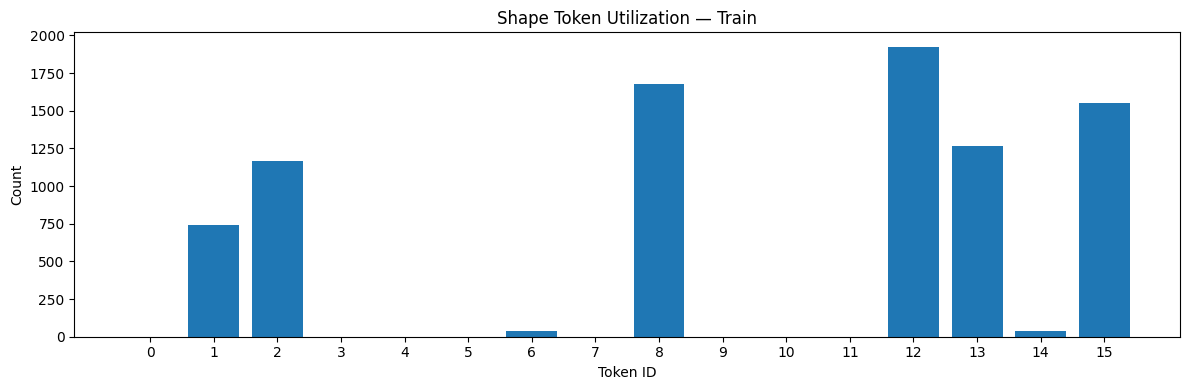

In [63]:
hist = train_util.histogram
all_tokens = list(range(CODEBOOK_SIZE))
counts = [hist.get(token, 0) for token in all_tokens]

plt.figure(figsize=(12, 4))
plt.bar(all_tokens, counts)
plt.title("Shape Token Utilization — Train")
plt.xlabel("Token ID")
plt.ylabel("Count")
plt.xticks(all_tokens)
plt.tight_layout()
save_current_figure("01_token_histogram.png")
plt.show()

### 10.2 Mean Feature Heatmap by Token

token별 평균 7D feature vector를 heatmap으로 봅니다. 행마다 feature pattern이 다르게 보이면 shape quantization이 어느 정도 분리되고 있다는 신호입니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures/02_mean_feature_heatmap.png


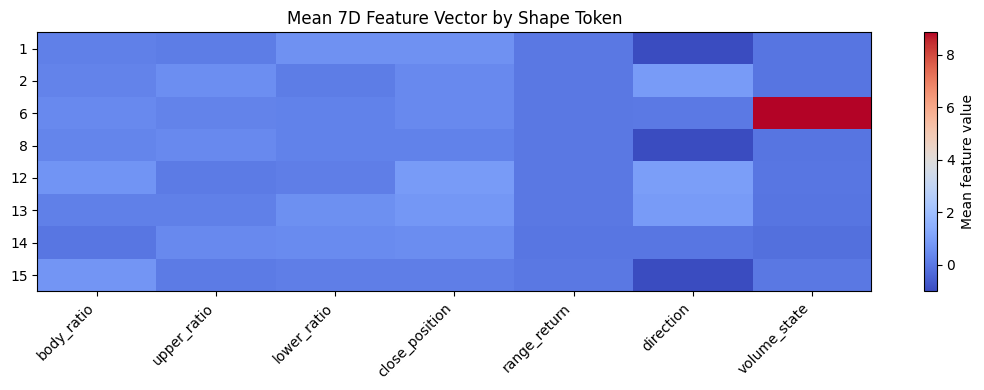

In [64]:
from collections import defaultdict

groups = defaultdict(list)
for token, feature in zip(train_tokens, train_features, strict=True):
    groups[token].append(feature.as_tuple())

active_tokens = sorted(groups)
token_means = {
    token: np.mean(groups[token], axis=0)
    for token in active_tokens
}

matrix = np.array([token_means[token] for token in active_tokens])

plt.figure(figsize=(11, max(4, len(active_tokens) * 0.35)))
plt.imshow(matrix, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean feature value")
plt.yticks(range(len(active_tokens)), active_tokens)
plt.xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45, ha="right")
plt.title("Mean 7D Feature Vector by Shape Token")
plt.tight_layout()
save_current_figure("02_mean_feature_heatmap.png")
plt.show()

### 10.3 Prototype Candle by Token

자주 등장한 token의 평균 shape를 candle glyph로 그립니다. 여기서는 가격 scale이 아니라 `body_ratio`, `upper_ratio`, `lower_ratio`, `direction`만 사용한 prototype입니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures/03_prototype_candles.png


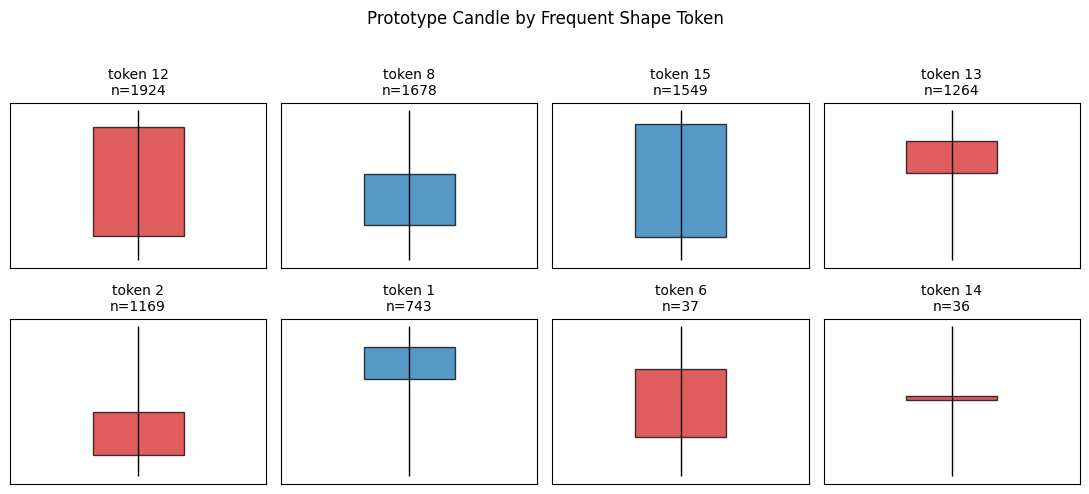

In [65]:
def draw_candle_prototype(ax, mean_feature, *, title: str) -> None:
    body_ratio = max(float(mean_feature[0]), 0.0)
    upper_ratio = max(float(mean_feature[1]), 0.0)
    lower_ratio = max(float(mean_feature[2]), 0.0)
    direction = float(mean_feature[5])

    total = body_ratio + upper_ratio + lower_ratio
    if total <= 0:
        body_ratio, upper_ratio, lower_ratio = 0.02, 0.0, 0.0
        total = body_ratio

    # Normalize to a fixed visual height.
    body = body_ratio / total
    upper = upper_ratio / total
    lower = lower_ratio / total

    if direction >= 0:
        open_y = lower
        close_y = lower + body
        color = "tab:red"
    else:
        close_y = lower
        open_y = lower + body
        color = "tab:blue"

    low_y = 0.0
    high_y = lower + body + upper
    body_height = max(abs(close_y - open_y), 0.025)

    ax.vlines(0, low_y, high_y, color="black", linewidth=1)
    ax.add_patch(
        plt.Rectangle(
            (-0.16, min(open_y, close_y)),
            0.32,
            body_height,
            facecolor=color,
            edgecolor="black",
            alpha=0.75,
        )
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.45, 0.45)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)


top_tokens = sorted(hist, key=hist.get, reverse=True)[: min(12, len(hist))]
cols = 4
rows = int(np.ceil(len(top_tokens) / cols)) or 1
fig, axes = plt.subplots(rows, cols, figsize=(11, rows * 2.4))
axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for ax, token in zip(axes, top_tokens, strict=False):
    ax.axis("on")
    draw_candle_prototype(
        ax,
        token_means[token],
        title=f"token {token}\nn={hist[token]}",
    )

plt.suptitle("Prototype Candle by Frequent Shape Token", y=1.02)
plt.tight_layout()
save_current_figure("03_prototype_candles.png")
plt.show()

### 10.4 Feature Scatter: Body vs Close Position

가장 단순한 2D projection으로 token 분리가 눈에 보이는지 확인합니다. 필요하면 x/y feature를 바꿔가며 봅니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures/04_feature_scatter_body_close_position.png


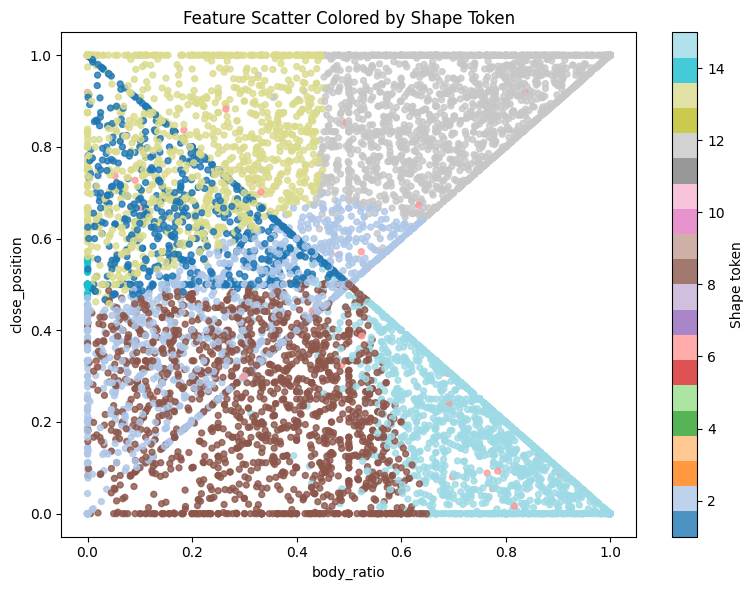

In [66]:
feature_matrix = np.array([feature.as_tuple() for feature in train_features])

x_index = FEATURE_NAMES.index("body_ratio")
y_index = FEATURE_NAMES.index("close_position")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    feature_matrix[:, x_index],
    feature_matrix[:, y_index],
    c=train_tokens,
    cmap="tab20",
    s=18,
    alpha=0.8,
)
plt.colorbar(scatter, label="Shape token")
plt.xlabel(FEATURE_NAMES[x_index])
plt.ylabel(FEATURE_NAMES[y_index])
plt.title("Feature Scatter Colored by Shape Token")
plt.tight_layout()
save_current_figure("04_feature_scatter_body_close_position.png")
plt.show()

## 11. Visual Diagnostics — Phase 2 Sequential Dynamics Preview

Phase 2는 아직 본격 연구 전이지만, shape token transition이 완전히 random처럼 보이는지 아닌지 빠르게 확인합니다.

### 11.1 Transition Matrix Heatmap

현재 token에서 다음 token으로 이동할 확률을 heatmap으로 봅니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures/05_transition_matrix_heatmap.png


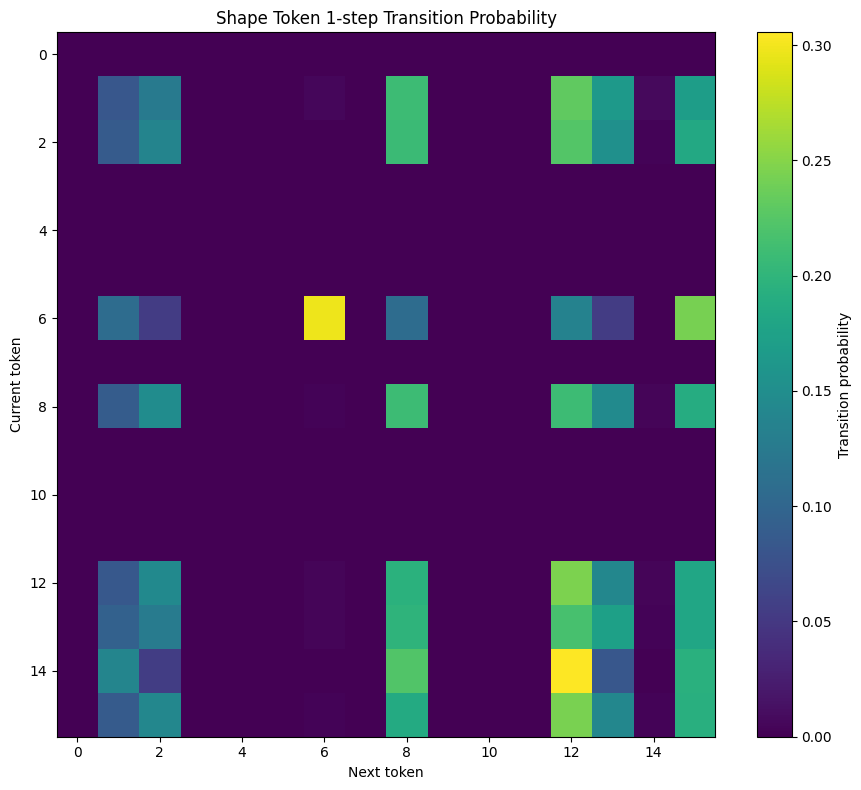

In [67]:
K = CODEBOOK_SIZE
transition_matrix = np.zeros((K, K), dtype=float)

for (source, target), count in train_transition.counts.items():
    transition_matrix[source, target] = count

row_sums = transition_matrix.sum(axis=1, keepdims=True)
transition_prob = np.divide(
    transition_matrix,
    row_sums,
    out=np.zeros_like(transition_matrix),
    where=row_sums != 0,
)

plt.figure(figsize=(9, 8))
plt.imshow(transition_prob, cmap="viridis", aspect="auto")
plt.colorbar(label="Transition probability")
plt.title("Shape Token 1-step Transition Probability")
plt.xlabel("Next token")
plt.ylabel("Current token")
plt.tight_layout()
save_current_figure("05_transition_matrix_heatmap.png")
plt.show()

### 11.2 Token Sequence Over Time

시간축에서 token이 뭉쳐 나오는 구간이 있는지 확인합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/runs/shape_quantization_NASDAQ_NVDA_1m_k16/figures/06_token_sequence_over_time.png


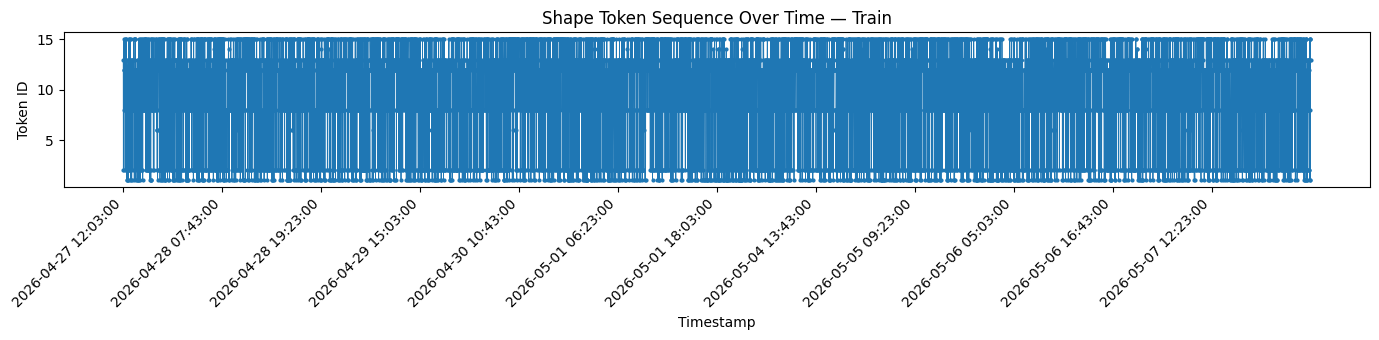

In [68]:
dates = [candle.timestamp for candle in split.train]
step = max(1, len(dates) // 12)

plt.figure(figsize=(14, 3.5))
plt.plot(dates, train_tokens, marker=".", linestyle="-", linewidth=0.6, markersize=4)
plt.title("Shape Token Sequence Over Time — Train")
plt.xlabel("Timestamp")
plt.ylabel("Token ID")
plt.xticks(dates[::step], rotation=45, ha="right")
plt.tight_layout()
save_current_figure("06_token_sequence_over_time.png")
plt.show()

## 12. Next Experiments

이 notebook이 정상 실행되면 다음 실험을 진행합니다.

1. `CODEBOOK_SIZE = 16, 32, 64` 비교
2. `SYMBOL` 변경: AAPL, MSFT, NVDA, RKLB 등
3. `EPOCHS`, `LATENT_DIM`, `HIDDEN_DIM` 변경
4. token별 representative candle shape 요약 강화
5. shuffled baseline과 transition structure 비교

아직 하지 않는 것:

- future return prediction
- trading signal
- backtest
- dashboard